# Cómo usar SynaptIX v0.1.7

**SynaptIX** es una librería integral de Machine Learning para Python que unifica todo el ciclo de ML bajo una sola API en español: `fit / predict / evaluate / save / load`.

Este notebook documenta **cada módulo, sus clases, funciones y parámetros**, con ejemplos ejecutables, y cierra con un **ejemplo completo bien documentado**.

## Índice

| # | Módulo | Contenido |
|---|--------|-----------|
| 1 | `synaptix.datasets` | Datasets de ejemplo incluidos |
| 2 | `synaptix.preprocessing` | Escalado, codificación, imputación, outliers, limpieza automática |
| 3 | `synaptix.supervised` | 8 regresores + 7 clasificadores + 9 bayesianos |
| 4 | `synaptix.unsupervised` | Clustering y reducción de dimensionalidad |
| 5 | `synaptix.reinforcement` | Q-Learning, SARSA, DQN y GridWorld |
| 6 | `synaptix.neural` | Redes MLP, CNN y LSTM (requiere tensorflow) |
| 7 | `synaptix.metrics` | Métricas de evaluación |
| 8 | `synaptix.model_selection` | Validación cruzada, GridSearch, compare_models |
| 9 | `synaptix.visualization` | Gráficas a partir de datos (EDA) y de modelos |
| 10 | `synaptix.legacy` | API clásica v0.x |
| 11 | `synaptix.pipeline` | AutoPipeline y Pipeline declarativo (nuevo en 0.1.7) |
| 12 | **Ejemplo final** | Pipeline completo de principio a fin |

## Instalación

```bash
pip install synaptix          # núcleo (sklearn, pandas, matplotlib)
pip install synaptix[dl]      # + tensorflow (módulo neural y DQNAgent)
pip install synaptix[bayes]   # + pymc (inferencia bayesiana completa)
pip install synaptix[all]     # todo
```

In [1]:
# Importar la librería y ver el resumen de módulos disponibles
import synaptix as sx

print(f"Versión: {sx.__version__}\n")
sx.welcome()

Versión: 0.1.7

SynaptIX v0.1.7
Librería integral de Machine Learning para Python
Autor: Emmanuel Ascendra

Submódulos disponibles:
  - synaptix.pipeline        : AutoPipeline (ML automático)
  - synaptix.preprocessing   : limpieza y transformación de datos
  - synaptix.supervised      : regresión, clasificación y bayesianos
  - synaptix.unsupervised    : clustering y reducción de dimensión
  - synaptix.reinforcement   : aprendizaje por refuerzo
  - synaptix.neural          : redes neuronales (MLP, CNN, LSTM)
  - synaptix.metrics         : métricas de evaluación
  - synaptix.model_selection : validación y comparación de modelos
  - synaptix.visualization   : gráficos de análisis
  - synaptix.datasets        : datasets de ejemplo

Repositorio: https://github.com/GhostAnalyst30/SynaptIX


## 1. `synaptix.datasets` — Datasets incluidos

| Función | Parámetros | Descripción |
|---------|------------|-------------|
| `load_dataset(name)` | `name: str` — nombre con o sin extensión `.csv` | Carga el dataset como DataFrame de pandas |
| `list_datasets()` | — | Lista los datasets disponibles |

**Datasets incluidos:**

| Nombre | Filas | Uso típico |
|--------|-------|------------|
| `iris` | 150 | Clasificación multiclase (el clásico) |
| `penguins` | 344 | Clasificación con nulos reales y categóricas |
| `titanic` | 418 | Clasificación binaria |
| `sp500_companies` | ~500 | Regresión y clustering financiero |
| `course_completion` | grande | Pipelines más realistas |

In [2]:
# Listar los datasets disponibles y cargar uno
print(sx.list_datasets())

df = sx.load_dataset("iris")   # acepta "iris" o "iris.csv"
df.head()

['iris', 'penguins', 'titanic', 'sp500_companies', 'course_completion']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. `synaptix.preprocessing` — Preprocesamiento de datos

Todas las clases siguen el patrón `fit / transform / fit_transform` y devuelven DataFrames preservando los nombres de columna.

| Clase / Función | Parámetros principales | Descripción |
|-----------------|------------------------|-------------|
| `Scaler(method)` | `method`: `"standard"` (media 0, desv 1), `"minmax"` (rango [0,1]), `"robust"` (mediana/IQR, resistente a outliers) | Escalado de numéricas. Tiene `inverse_transform` |
| `Encoder(method)` | `method`: `"onehot"` (columna binaria por categoría), `"label"` (entero por categoría). `fit(df, columns=None)` detecta las categóricas si no se indican | Codificación de categóricas |
| `Imputer(strategy, fill_value)` | `strategy`: `"mean"`, `"median"`, `"most_frequent"`, `"constant"`. Las categóricas siempre usan la moda | Relleno de valores faltantes (NaN) |
| `DataCleaner(impute_strategy, encode_method, scale_method)` | `impute_strategy="median"`, `encode_method="onehot"`, `scale_method="standard"` (o `None` para no escalar) | Limpieza automática completa |
| → `.analyze(df, verbose=True)` | — | Reporta nulos, duplicados, outliers, tipos y cardinalidad |
| → `.clean(df, target=None, drop_duplicates=True)` | `target` se preserva sin transformar | Aplica imputar → codificar → escalar |
| `detect_outliers(df, columns, method, threshold)` | `method`: `"iqr"` (threshold=1.5) o `"zscore"` (threshold=3.0 recomendado) | Máscara booleana de outliers por columna |
| `remove_outliers(df, columns, method, threshold)` | Igual que `detect_outliers` | Elimina las filas con outliers |
| `train_test_split(X, y, test_size, random_state, ...)` | El de scikit-learn, re-exportado | División train/test |

In [3]:
from synaptix.preprocessing import (
    Scaler, Encoder, Imputer, DataCleaner,
    detect_outliers, remove_outliers, train_test_split,
)

# El dataset penguins tiene nulos reales y columnas categóricas
penguins = sx.load_dataset("penguins")

# 1) Analizar la calidad de los datos (nulos, outliers, tipos...)
cleaner = DataCleaner(impute_strategy="median", scale_method="standard")
reporte = cleaner.analyze(penguins)

# 2) Limpiar todo de una vez (imputa -> codifica -> escala)
penguins_listo = cleaner.clean(penguins, target="species")
penguins_listo.head()


=== Análisis del DataFrame ===
  Filas               : 344
  Numéricas           : 4 -> ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
  Categóricas         : 3 -> ['species', 'island', 'sex']
  Duplicados          : 0
  Nulos por columna   :
    bill_length_mm: 2 (0.6%)
    bill_depth_mm: 2 (0.6%)
    flipper_length_mm: 2 (0.6%)
    body_mass_g: 2 (0.6%)
    sex: 11 (3.2%)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE,species
0,-0.887622,0.787289,-1.420541,-0.564625,-0.977008,-0.750757,2.36968,-0.960098,0.960098,Adelie
1,-0.814037,0.126114,-1.063485,-0.502010,-0.977008,-0.750757,2.36968,1.041561,-1.041561,Adelie
2,-0.666866,0.431272,-0.420786,-1.190773,-0.977008,-0.750757,2.36968,1.041561,-1.041561,Adelie
3,0.096581,0.075255,-0.277964,-0.188936,-0.977008,-0.750757,2.36968,-0.960098,0.960098,Adelie
4,-1.329133,1.092447,-0.563608,-0.940314,-0.977008,-0.750757,2.36968,1.041561,-1.041561,Adelie


In [4]:
# También se puede usar cada transformador por separado
numericas = penguins.select_dtypes("number").dropna()

X_escalado = Scaler("robust").fit_transform(numericas)       # resistente a outliers
sin_nulos = Imputer("median").fit_transform(penguins)        # rellena NaN
codificado = Encoder("onehot").fit_transform(penguins.dropna(), columns=["island"])

# Outliers con el método IQR
mask = detect_outliers(numericas, method="iqr", threshold=1.5)
print("Outliers por columna:")
print(mask.sum())

sin_outliers = remove_outliers(numericas, method="iqr")
print(f"\nFilas: {len(numericas)} -> {len(sin_outliers)} tras quitar outliers")

Outliers por columna:
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64

Filas: 342 -> 342 tras quitar outliers


## 3. `synaptix.supervised` — Aprendizaje supervisado

Los 15 modelos comparten la **misma API** (heredada de `SynaptixModel`):

| Método | Parámetros | Descripción |
|--------|------------|-------------|
| `.fit(X, y)` | DataFrames, arrays o listas | Entrena el modelo |
| `.predict(X)` | — | Predicciones |
| `.predict_proba(X)` | Solo clasificadores compatibles | Probabilidades por clase |
| `.evaluate(X, y, plot=False, verbose=True)` | `plot=True` muestra gráficos | Imprime y devuelve métricas |
| `.score(X, y)` | — | R² (regresión) o accuracy (clasificación) |
| `.summary()` | — | Tipo, tarea, features y parámetros |
| `.feature_importances()` | — | Serie ordenada (árboles y lineales) |
| `.save(path)` / `Clase.load(path)` | Ruta `.pkl` | Persistencia |

### Regresión

| Modelo | Parámetros principales |
|--------|------------------------|
| `LinearRegression()` | `fit_intercept=True` |
| `RidgeRegression(alpha=1.0)` | `alpha`: fuerza de regularización L2 |
| `LassoRegression(alpha=1.0)` | `alpha`: regularización L1 (lleva coeficientes a 0 → selección de features) |
| `DecisionTreeRegressor(max_depth=None)` | `max_depth`, `random_state=42` |
| `RandomForestRegressor(n_estimators=100)` | `n_estimators`, `max_depth`, `random_state` |
| `GradientBoostingRegressor(n_estimators=100, learning_rate=0.1)` | `n_estimators`, `learning_rate` |
| `SVR(kernel="rbf", C=1.0)` | `kernel`: linear / poly / rbf / sigmoid |
| `KNNRegressor(n_neighbors=5)` | `n_neighbors` |

### Clasificación

| Modelo | Parámetros principales |
|--------|------------------------|
| `LogisticRegression(C=1.0, max_iter=1000)` | `C`: inverso de la regularización |
| `DecisionTreeClassifier(max_depth=None)` | `max_depth`, `random_state` |
| `RandomForestClassifier(n_estimators=100)` | `n_estimators`, `max_depth`, `random_state` |
| `GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)` | `n_estimators`, `learning_rate` |
| `SVMClassifier(kernel="rbf", C=1.0, probability=True)` | `probability=True` habilita `predict_proba` |
| `KNNClassifier(n_neighbors=5)` | `n_neighbors` |
| `NaiveBayes()` | Gaussiano, sin parámetros obligatorios |

> Todos aceptan `**kwargs` que se pasan directamente al estimador de scikit-learn subyacente.

In [5]:
from synaptix.supervised import RandomForestClassifier, LogisticRegression

# Preparar iris
iris = sx.load_dataset("iris")
X, y = iris.drop(columns="species"), iris["species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar y evaluar (misma API para cualquier modelo)
rf = RandomForestClassifier(n_estimators=100, max_depth=5)
rf.fit(X_train, y_train)
rf.evaluate(X_test, y_test)

# Importancia de features e inspección
print("\nImportancia de features:")
print(rf.feature_importances())

# Persistencia
rf.save("modelo_iris.pkl")
rf_cargado = RandomForestClassifier.load("modelo_iris.pkl")
print("\nModelo cargado:", rf_cargado)


=== Evaluación: RandomForestClassifier ===
  accuracy    : 1.0000
  precision   : 1.0000
  recall      : 1.0000
  f1          : 1.0000

Importancia de features:
petal_length    0.445257
petal_width     0.420793
sepal_length    0.105913
sepal_width     0.028037
dtype: float64



Modelo cargado: <RandomForestClassifier (classification, entrenado)>


### 3.1 Modelos bayesianos *(nuevos en v0.1.7)*

Modelos que aprenden **distribuciones** en lugar de valores puntuales, por lo que pueden reportar **incertidumbre** en sus predicciones.

#### Wrappers de scikit-learn (sin dependencias extra)

| Modelo | Parámetros principales | Método extra |
|--------|------------------------|--------------|
| `BayesianRidgeRegression(max_iter=300)` | `alpha_1`, `alpha_2`, `lambda_1`, `lambda_2` (priors gamma) | `predict_interval(X, std=2)` → `(media, inferior, superior)` |
| `ARDRegression(max_iter=300)` | Igual que BayesianRidge; poda features irrelevantes | `predict_interval(X, std=2)` |
| `GaussianProcessRegressor(kernel=None, normalize_y=True)` | `kernel` por defecto: `ConstantKernel * RBF + WhiteKernel`. El intervalo se ensancha lejos de los datos. Escala O(n³): para datasets chicos | `predict_interval(X, std=2)` |
| `GaussianProcessClassifier(kernel=None)` | `kernel` por defecto: `ConstantKernel * RBF` | `predict_proba` |
| `MultinomialNB(alpha=1.0)` | `alpha`: suavizado. Para conteos (texto); features no negativas | — |
| `BernoulliNB(alpha=1.0, binarize=0.0)` | `binarize`: umbral para binarizar las features | — |
| `ComplementNB(alpha=1.0)` | Robusto a clases desbalanceadas; features no negativas | — |

#### Inferencia completa con PyMC *(requiere `pip install synaptix[bayes]`)*

| Modelo | Parámetros | Métodos |
|--------|------------|---------|
| `PyMCLinearRegression(draws=1000, tune=1000, chains=2)` | `draws`: muestras MCMC por cadena; `tune`: calentamiento; `chains`: cadenas | `predict` (media posterior), `predict_interval(X, hdi=0.94)` (intervalo creíble), `summary()`, `plot_posterior()` |
| `PyMCLogisticRegression(...)` | Igual; solo clasificación **binaria** | `predict`, `predict_proba`, `summary()`, `plot_posterior()` |

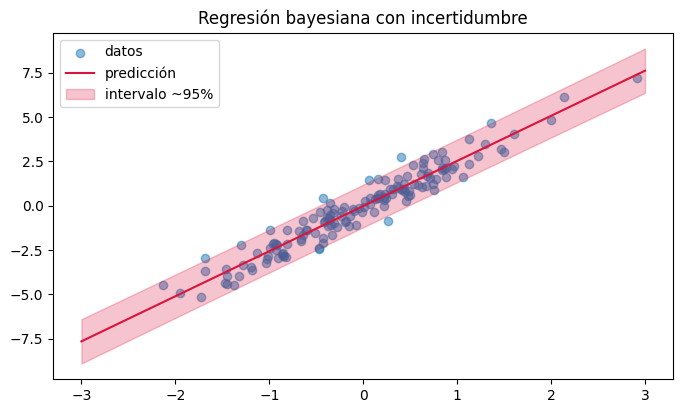

In [6]:
from synaptix.supervised import BayesianRidgeRegression
import numpy as np
import matplotlib.pyplot as plt

# Datos sintéticos de regresión
rng = np.random.default_rng(42)
X_reg = rng.normal(0, 1, (150, 1))
y_reg = 2.5 * X_reg[:, 0] + rng.normal(0, 0.6, 150)

# Entrenar y predecir CON incertidumbre
bayes = BayesianRidgeRegression()
bayes.fit(X_reg, y_reg)

X_grid = np.linspace(-3, 3, 100).reshape(-1, 1)
media, inferior, superior = bayes.predict_interval(X_grid, std=2)  # ~95%

plt.figure(figsize=(8, 4.5))
plt.scatter(X_reg, y_reg, alpha=0.5, label="datos")
plt.plot(X_grid, media, color="crimson", label="predicción")
plt.fill_between(X_grid.ravel(), inferior, superior, alpha=0.25,
                 color="crimson", label="intervalo ~95%")
plt.legend(); plt.title("Regresión bayesiana con incertidumbre"); plt.show()

## 4. `synaptix.unsupervised` — Aprendizaje no supervisado

### Clustering — todos tienen `fit(X)`, `fit_predict(X)`, `silhouette(X)` y `plot(X, features=(0,1))`

| Modelo | Parámetros principales | Notas |
|--------|------------------------|-------|
| `KMeans(n_clusters=3)` | `n_clusters`, `random_state=42` | `.centroids_` tras el ajuste |
| `KMeans.elbow(X, k_max=10, plot=True)` | *(estático)* | Método del codo para elegir k |
| `KMeans.silhouette_scores(X, k_max=10, plot=True)` | *(estático)* | Silhouette para k=2..k_max |
| `DBSCAN(eps=0.5, min_samples=5)` | `eps`: radio de vecindad | No requiere k; etiqueta `-1` = ruido |
| `HierarchicalClustering(n_clusters=3, linkage="ward")` | `linkage`: ward / complete / average / single | Aglomerativo |
| `GaussianMixture(n_components=3)` | `n_components` | Probabilístico; tiene `predict_proba(X)` |

### Reducción de dimensionalidad

| Modelo | Parámetros principales | Métodos |
|--------|------------------------|---------|
| `PCA(n_components=2)` | Entero, o fracción de varianza (ej. `0.95`) | `fit_transform`, `inverse_transform`, `explained_variance()`, `plot_variance()` |
| `TSNE(n_components=2, perplexity=30.0)` | `perplexity`: balance local/global (5–50) | `fit_transform(X)`, `plot(X, labels=None)` |

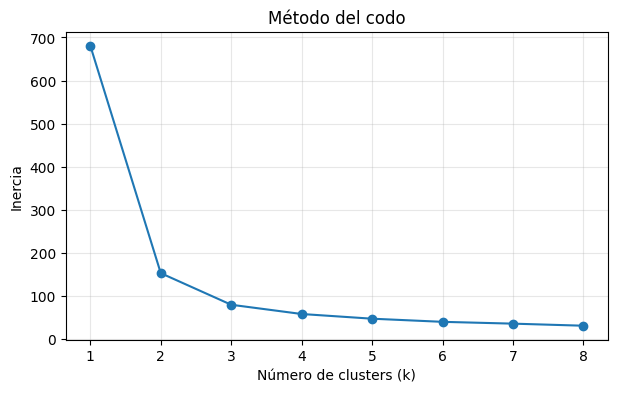

Silhouette: 0.551


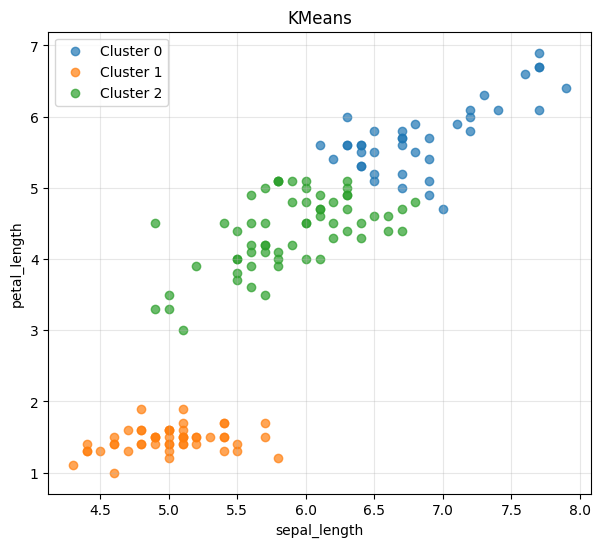


Varianza explicada por componente:
PC1    0.924616
PC2    0.053016
Name: varianza, dtype: float64


In [7]:
from synaptix.unsupervised import KMeans, PCA

X_iris = iris.drop(columns="species")

# 1) Elegir k con el método del codo
KMeans.elbow(X_iris, k_max=8)

# 2) Agrupar y medir calidad
km = KMeans(n_clusters=3)
labels = km.fit_predict(X_iris)
print(f"Silhouette: {km.silhouette(X_iris):.3f}")
km.plot(X_iris, features=(0, 2))   # scatter coloreado por cluster

# 3) Reducir a 2D con PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_iris)
print("\nVarianza explicada por componente:")
print(pca.explained_variance())

## 5. `synaptix.reinforcement` — Aprendizaje por refuerzo

### Entorno

| Clase | Parámetros | Descripción |
|-------|------------|-------------|
| `GridWorld(rows=4, cols=4, start=(0,0), goal=None, obstacles=None, max_steps=200)` | `goal` por defecto es la esquina inferior derecha; `obstacles` es lista de tuplas `(fila, col)` | Rejilla 2D. Recompensas: **+10** meta, **-1** por paso, **-5** por chocar. Interfaz `reset()` / `step(action)` estilo Gymnasium. Acciones: 0=↑ 1=→ 2=↓ 3=← |
| → `.render(policy=None)` | Si se pasa `agent.policy()` dibuja flechas | Imprime la rejilla en consola |

### Agentes tabulares (`QLearningAgent` y `SARSAAgent`)

| Parámetro | Default | Significado |
|-----------|---------|-------------|
| `n_states`, `n_actions` | — | Dimensiones de la tabla Q |
| `alpha` | 0.1 | Tasa de aprendizaje |
| `gamma` | 0.99 | Descuento de recompensas futuras |
| `epsilon` | 1.0 | Probabilidad inicial de explorar |
| `epsilon_min` / `epsilon_decay` | 0.01 / 0.995 | Decaimiento de la exploración por episodio |

Métodos: `train(env, episodes=500, verbose=False)`, `act(state, greedy=False)`, `policy()`, `plot_rewards(window=20)`.

- **Q-Learning** es *off-policy*: aprende del máximo Q del siguiente estado.
- **SARSA** es *on-policy*: aprende de la acción que realmente toma (más conservador).

### `DQNAgent` — Deep Q-Network (requiere `synaptix[dl]`)

| Parámetro | Default | Significado |
|-----------|---------|-------------|
| `state_dim`, `n_actions` | — | Dimensión del estado vectorial y acciones |
| `hidden_layers` | `(64, 64)` | Neuronas por capa |
| `buffer_size` / `batch_size` | 10000 / 64 | Experience replay |
| `target_update_every` | 10 | Episodios entre actualizaciones de la red objetivo |

Para entornos con **estados continuos** donde una tabla Q no es viable.

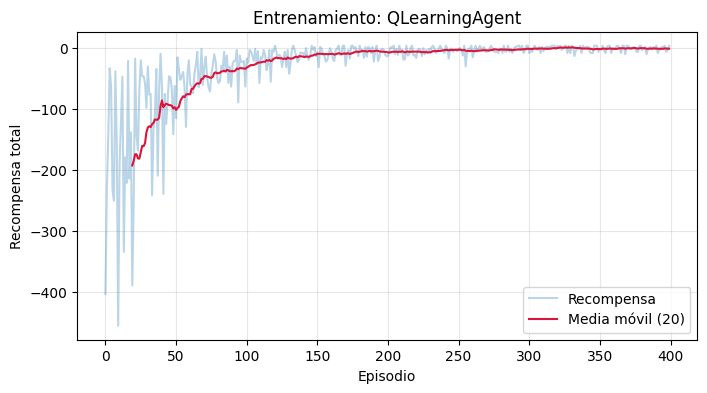

Política aprendida (S=inicio, G=meta, #=obstáculo):

| → | → | ↓ | ↓ | ↓ |
| ↓ | # | → | → | ↓ |
| → | → | ↓ | # | ↓ |
| ↓ | # | ↓ | ↓ | ↓ |
| → | → | → | → | G |



In [8]:
from synaptix.reinforcement import GridWorld, QLearningAgent

# Crear un mundo 5x5 con obstáculos
env = GridWorld(rows=5, cols=5, obstacles=[(1, 1), (2, 3), (3, 1)])

# Entrenar un agente Q-Learning
agent = QLearningAgent(
    n_states=env.n_states,
    n_actions=env.n_actions,
    alpha=0.1,      # tasa de aprendizaje
    gamma=0.99,     # descuento
    epsilon=1.0,    # exploración inicial (decae solo)
    seed=42,
)
rewards = agent.train(env, episodes=400)

# Curva de recompensas y política aprendida
agent.plot_rewards(window=20)
print("Política aprendida (S=inicio, G=meta, #=obstáculo):")
env.render(agent.policy())

## 6. `synaptix.neural` — Redes neuronales *(requiere `pip install synaptix[dl]`)*

### `MLP` — perceptrón multicapa para tabulares

| Parámetro | Default | Significado |
|-----------|---------|-------------|
| `task` | `"regression"` | `"regression"` o `"classification"` (detecta binaria → sigmoid, multiclase → softmax) |
| `hidden_layers` | `(64, 32)` | Neuronas por capa oculta |
| `activation` | `"relu"` | Activación de capas ocultas |
| `dropout` | `0.0` | Dropout tras cada capa |
| `scale` | `True` | Escala las features internamente (StandardScaler) |
| `optimizer` | `"adam"` | Optimizador de Keras |

`fit(X, y, epochs=100, batch_size=32, validation_split=0.2, early_stopping=True, verbose=1)` — las etiquetas pueden ser strings, se codifican/decodifican solas. Métodos: `predict`, `predict_proba`, `evaluate`, `plot_history()`, `summary()`, `save/load`.

### `CNN` — clasificación de imágenes

| Parámetro | Default | Significado |
|-----------|---------|-------------|
| `input_shape` | — | Forma de la imagen, ej. `(28, 28, 1)` |
| `n_classes` | — | Número de clases |
| `conv_blocks` | `(32, 64)` | Filtros por bloque Conv2D + MaxPooling |
| `dense_units` | `128` | Neuronas de la capa densa final |
| `dropout` | `0.3` | Dropout antes de la salida |

### `LSTMNet` — series de tiempo

| Parámetro | Default | Significado |
|-----------|---------|-------------|
| `window` | `10` | Pasos previos usados para predecir el siguiente |
| `units` | `(50,)` | Unidades por capa LSTM |
| `scale` | `True` | Escala la serie a [0,1] internamente |

`fit(serie, epochs=50)` recibe una serie 1D y crea las ventanas solo. `forecast(serie, steps=n)` predice `n` pasos futuros de forma autorregresiva, en la escala original. También tiene el helper estático `make_windows(serie, window)`.


=== Evaluación: MLP ===
  accuracy    : 0.9000
  precision   : 0.9214
  recall      : 0.9000
  f1          : 0.8960


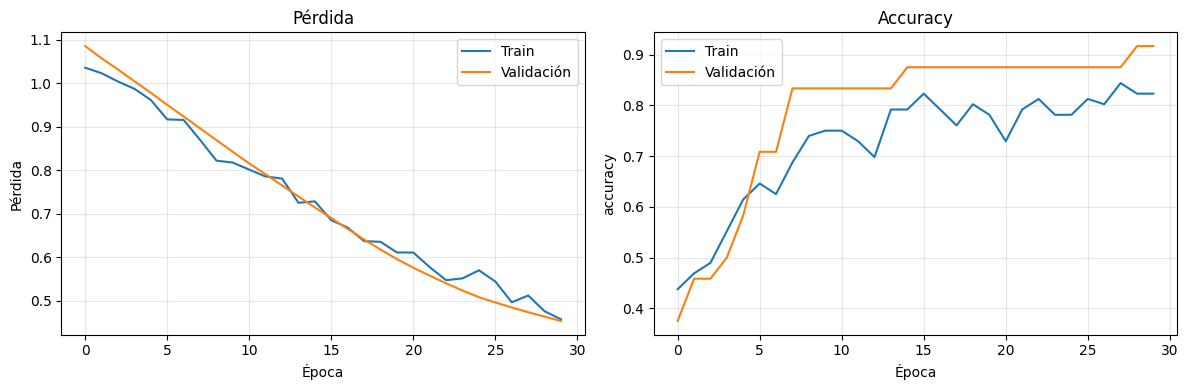

In [9]:
# Requiere tensorflow (pip install synaptix[dl]); si no está, esta celda se omite
try:
    import tensorflow  # noqa: F401

    from synaptix.neural import MLP

    net = MLP(task="classification", hidden_layers=(32, 16), dropout=0.2)
    net.fit(X_train, y_train, epochs=30, verbose=0)   # early stopping incluido
    net.evaluate(X_test, y_test)
    net.plot_history()   # curvas de pérdida y accuracy
except ImportError:
    print("tensorflow no está instalado — instala con: pip install synaptix[dl]")

## 7. `synaptix.metrics` — Métricas de evaluación

| Función | Parámetros | Devuelve |
|---------|------------|----------|
| `regression_metrics(y_true, y_pred)` | — | `{"MAE", "MSE", "RMSE", "R2", "MAPE"}` (MAPE en %, se omite si hay ceros) |
| `classification_metrics(y_true, y_pred, average="weighted")` | `average`: weighted / macro / micro | `{"accuracy", "precision", "recall", "f1"}` |
| `clustering_metrics(X, labels)` | — | `{"silhouette", "calinski_harabasz", "davies_bouldin"}` (los dos primeros: mayor mejor; el último: menor mejor) |
| `classification_report(y_true, y_pred, plot=False, labels=None)` | `plot=True` grafica la matriz de confusión | Métricas globales + desglose por clase (`"por_clase"`) |

> Nota: `model.evaluate(X, y)` de cualquier modelo supervisado ya usa estas funciones internamente.

{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

=== Reporte de clasificación ===
  accuracy  : 1.0000
  precision : 1.0000
  recall    : 1.0000
  f1        : 1.0000

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



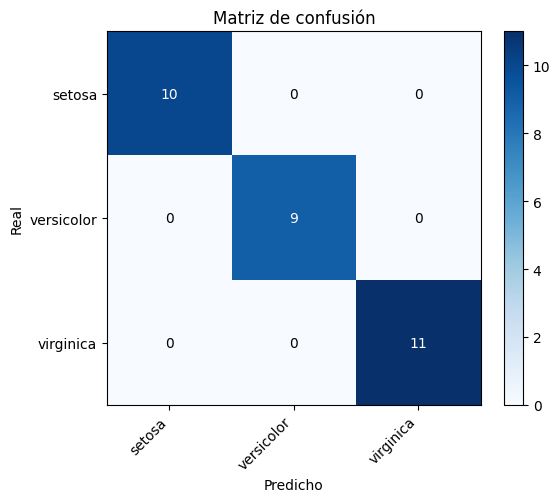

In [10]:
from synaptix.metrics import classification_metrics, regression_metrics, classification_report

y_pred = rf.predict(X_test)

# Diccionario de métricas
print(classification_metrics(y_test, y_pred))

# Reporte completo con matriz de confusión
reporte = classification_report(y_test, y_pred, plot=True)

## 8. `synaptix.model_selection` — Validación y selección de modelos

| Función / Clase | Parámetros | Descripción |
|-----------------|------------|-------------|
| `cross_validate(model, X, y, cv=5, scoring=None, verbose=True)` | `scoring`: métrica de sklearn (`"accuracy"`, `"r2"`, `"f1_weighted"`, ...). Default según la tarea | Devuelve `{"scores", "media", "desviacion"}` |
| `GridSearch(model, param_grid, cv=5, scoring=None)` | `param_grid`: dict de listas, ej. `{"n_estimators": [50, 100]}` | Prueba todas las combinaciones en paralelo |
| → `.fit(X, y)` | — | Devuelve el modelo re-entrenado con la mejor combinación; expone `.best_params_` y `.best_score_` |
| `compare_models(X, y, task="classification", cv=5, verbose=True)` | `task`: `"classification"` (7 modelos) o `"regression"` (7 modelos) | **AutoML-lite**: entrena todos los modelos con validación cruzada y devuelve un DataFrame rankeado con score, desviación y tiempo |

In [11]:
from synaptix.model_selection import compare_models, cross_validate, GridSearch
from synaptix.supervised import DecisionTreeClassifier

# ¿Qué modelo funciona mejor? Ranking automático con validación cruzada
tabla = compare_models(X, y, task="classification", cv=5, verbose=False)
display(tabla)

# Validación cruzada de un modelo puntual
cv = cross_validate(RandomForestClassifier(n_estimators=50), X, y, cv=5, verbose=False)
print(f"CV RandomForest: {cv['media']:.4f} +/- {cv['desviacion']:.4f}")

# Búsqueda de hiperparámetros en rejilla
search = GridSearch(
    DecisionTreeClassifier(),
    {"max_depth": [2, 4, 6, None]},
    cv=5,
)
mejor_arbol = search.fit(X, y, verbose=False)
print(f"Mejores parámetros: {search.best_params_} (score: {search.best_score_:.4f})")

,modelo,accuracy,desviacion,tiempo_s
0,LogisticRegression,0.973333,0.024944,0.213
1,KNNClassifier,0.973333,0.024944,0.035
2,RandomForestClassifier,0.966667,0.021082,2.265
3,SVMClassifier,0.966667,0.021082,0.033
4,GradientBoostingClassifier,0.960000,0.032660,3.628
5,DecisionTreeClassifier,0.953333,0.033993,0.034
6,NaiveBayes,0.953333,0.026667,0.020


CV RandomForest: 0.9667 +/- 0.0211


Mejores parámetros: {'max_depth': 4} (score: 0.9533)


## 9. `synaptix.visualization` — Gráficas a partir de datos y modelos

### A partir de datos (EDA)

| Función | Parámetros | Descripción |
|---------|------------|-------------|
| `plot_distributions(df, columns=None, bins=30)` | `columns`: por defecto todas las numéricas | Histogramas en grilla con media y mediana |
| `plot_correlation(df, columns=None, method="pearson")` | `method`: pearson / spearman / kendall | Heatmap de correlación con valores anotados |
| `plot_boxplots(df, columns=None, by=None)` | `by`: columna categórica para segmentar | Boxplots (detección visual de outliers) |
| `plot_scatter_matrix(df, columns=None, target=None, max_cols=6)` | `target`: colorear por clase | Matriz de dispersión entre pares |
| `plot_missing(df)` | — | % de valores faltantes por columna |

### A partir de modelos

| Función | Parámetros | Descripción |
|---------|------------|-------------|
| `plot_confusion_matrix(y_true, y_pred, labels=None)` | `labels`: nombres de las clases | Matriz de confusión |
| `plot_roc_curve(y_true, y_proba)` | `y_proba`: prob. de la clase positiva | Curva ROC con AUC (binaria) |
| `plot_learning_curve(model, X, y, cv=5)` | — | Train vs validación según tamaño de datos (diagnóstico de overfitting) |
| `plot_feature_importance(model, top_n=15)` | Modelo entrenado con importancias | Barras horizontales |
| `plot_clusters(X, labels, features=(0,1))` | — | Scatter 2D por cluster |
| `plot_predictions(y_true, y_pred)` | — | Real vs predicho (regresión) |
| `plot_residuals(model, X, y)` | Modelo de regresión entrenado | Residuos vs predicho + histograma |
| `plot_decision_boundary(model, X, y, features=(0,1), resolution=200)` | Reentrena una copia con 2 features | Regiones de decisión 2D |
| `model_report(model, X, y)` | Modelo entrenado | **Reporte completo automático**: métricas + gráficos según la tarea |

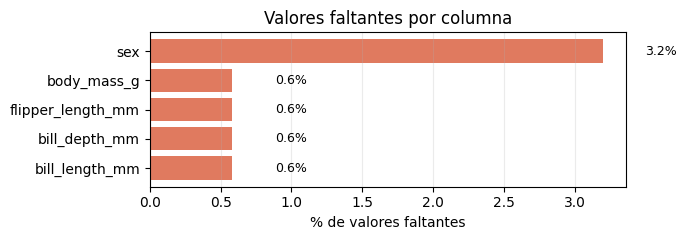

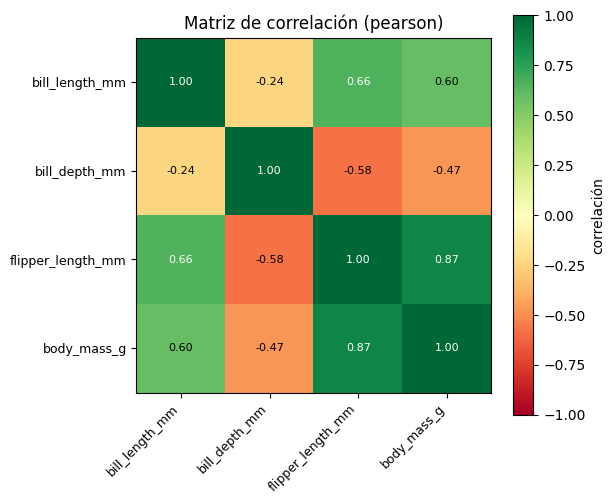

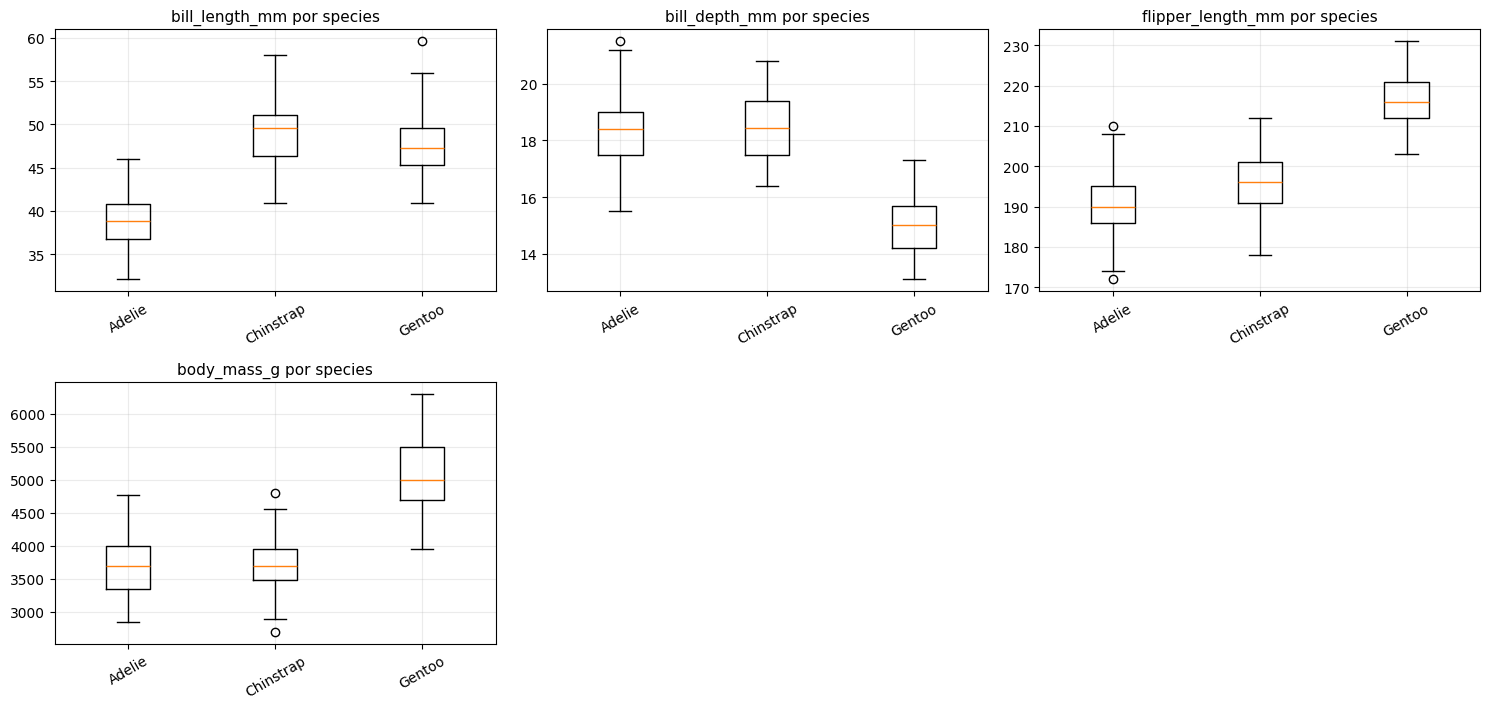

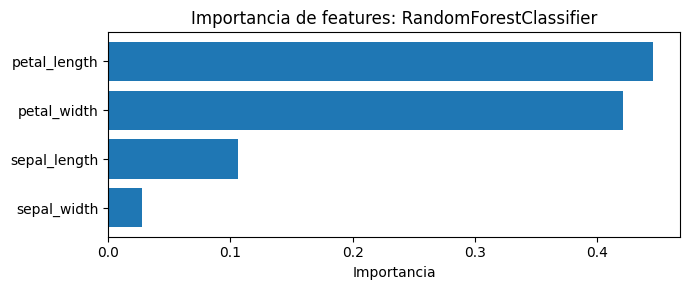

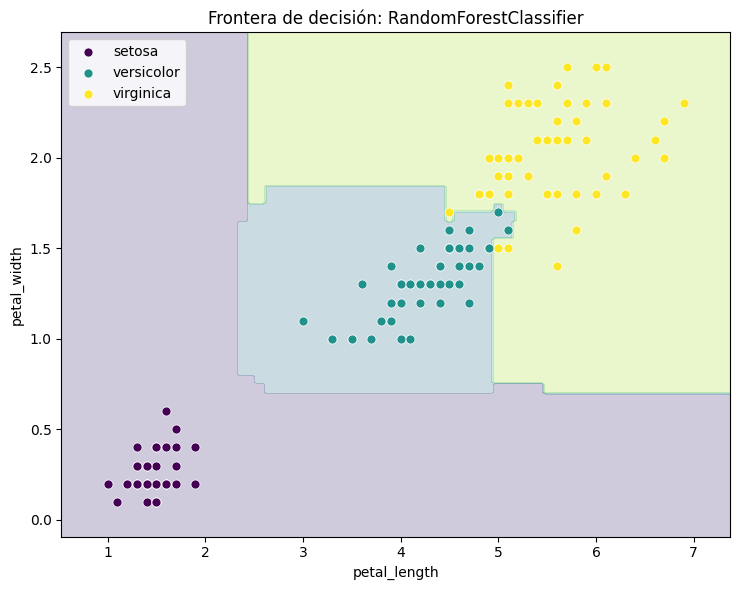

In [12]:
from synaptix.visualization import (
    plot_correlation, plot_boxplots, plot_missing,
    plot_decision_boundary, plot_feature_importance,
)

# EDA sobre penguins (tiene nulos y categorías)
plot_missing(penguins)
plot_correlation(penguins)
plot_boxplots(penguins, by="species")

# Gráficas a partir del modelo entrenado
plot_feature_importance(rf)
plot_decision_boundary(rf, X, y, features=(2, 3))   # petal length vs petal width

## 10. `synaptix.legacy` — API clásica v0.x

Se mantiene por compatibilidad con versiones anteriores:

| Clase | Descripción |
|-------|-------------|
| `IntelligenceArtificial(backend_ia=("mistral", ""))` | IA clásica: base de conocimiento (`add_fact(sujeto, predicado, valor)`), búsqueda (`bfs`, `dfs`, `a_star`), optimización (`genetic_algorithm`, `simulated_annealing`), agentes, chatbots y chat con LLMs vía OpenRouter. La API key se lee de la variable de entorno **`OPENROUTER_API_KEY`** |
| `MachineLearning(data)` | Pipeline de red neuronal Keras estilo v0.x (`neural_network()` → `data()` → `build()` → `fit()`) — requiere tensorflow |
| `NaturalLanguageProcessing(data)` | Stub de NLP (el alias con el typo original `NaturalLanguajeProcessing` sigue funcionando) |
| `DeepLearning(data)` | Stub de DL |

> Para código nuevo se recomiendan los submódulos modernos (secciones 1–9).

## 11. `synaptix.pipeline` — Pipelines automáticos *(nuevo en v0.1.7)*

Para usuarios sin experiencia: **el sistema se encarga de los parámetros**, pero todo se puede cambiar en código.

### `AutoPipeline` — todo automático en una llamada

| Parámetro | Default | Significado |
|-----------|---------|-------------|
| `task` | `None` | `"classification"` / `"regression"`; se detecta solo si es None |
| `models` | `None` | Subconjunto de modelos a comparar, ej. `["random_forest", "svm"]` |
| `cv` | `5` | Folds de validación cruzada |
| `tune` | `True` | Ajustar hiperparámetros del mejor con GridSearch |
| `test_size` | `0.2` | Fracción reservada para evaluación final |
| `impute_strategy` | `"median"` | Imputación de nulos |
| `encode_method` | `"onehot"` | Codificación de categóricas |
| `scale_method` | `"standard"` | Escalado (o `None`) |
| `param_grids` | `None` | Rejillas propias por modelo, ej. `{"random_forest": {"n_estimators": [300]}}` |
| `verbose` | `True` | Imprime el progreso de cada etapa |

Métodos: `fit(df, target)`, `predict(df_crudo)`, `predict_proba(df_crudo)`, `report(plot=True)`, `save(path)` / `AutoPipeline.load(path)`.

Atributos tras el fit: `task_`, `ranking_` (DataFrame comparativo), `best_model_`, `best_params_`, `results_`, `cleaner_`.

### `Pipeline` — declarativo por pasos

El usuario **lista los pasos** y el sistema rellena los parámetros; cada paso acepta overrides:

| Paso | Formas aceptadas | Default |
|------|------------------|---------|
| `clean` | `"clean"` o `("clean", {params de DataCleaner})` | mediana + one-hot + standard |
| `outliers` | `"outliers"` o `("outliers", {"method": "iqr", "threshold": 1.5})` | IQR 1.5 en numéricas |
| `model` | `"model"` (elige el mejor solo), `("model", "random_forest")` o `("model", "knn", {"n_neighbors": 9})` | comparación automática |
| `tune` | `"tune"` o `("tune", {"param_grid": {...}, "cv": 5})` | rejilla por defecto del modelo |
| `evaluate` | `"evaluate"` o `("evaluate", {"plot": True})` | métricas sin gráficos |

Modelos disponibles por nombre: `logistic`, `decision_tree`, `random_forest`, `gradient_boosting`, `svm`, `knn`, `naive_bayes`, `gaussian_process` (clasificación) y `linear`, `ridge`, `lasso`, `bayesian_ridge`, `decision_tree`, `random_forest`, `gradient_boosting`, `svm`, `knn`, `gaussian_process` (regresión).

In [13]:
# AutoPipeline: el sistema hace todo (limpiar, comparar, ajustar, evaluar)
pipe = sx.AutoPipeline(cv=3)
pipe.fit(penguins, target="species")

# Predicción sobre datos CRUDOS nuevos (con nulos y categóricas)
nuevos = penguins.drop(columns="species").head(5)
print("\nPredicciones:", pipe.predict(nuevos))

# Pipeline declarativo: tú pones los pasos, el sistema los parámetros
from synaptix.pipeline import Pipeline

pipe2 = Pipeline(
    [
        "clean",
        ("model", "random_forest", {"n_estimators": 50}),
        "tune",
        "evaluate",
    ],
    cv=3,
)
pipe2.fit(penguins, target="species")
print("\nParámetros elegidos por tune:", pipe2.best_params_)

[1/5] Tarea detectada: classification
[2/5] Datos limpios: 344 filas, 9 features (imputación, codificación y escalado aplicados)


[3/5] 7 modelos comparados (3 folds). Mejor: logistic (accuracy=0.9927)
[4/5] Hiperparámetros ajustados: {'C': 1.0}
[5/5] Evaluación final (accuracy en test): 0.9855

Predicciones: ['Adelie' 'Adelie' 'Adelie' 'Adelie' 'Adelie']
[1/4] clean: 9 features listas


[2/4] model: random_forest entrenado


[3/4] tune: mejores parámetros {'max_depth': 5, 'n_estimators': 50}
[4/4] evaluate: accuracy en test = 1.0000

Parámetros elegidos por tune: {'max_depth': 5, 'n_estimators': 50}


## 12. Ejemplo final: pipeline completo de principio a fin

Vamos a resolver un problema real con el dataset **penguins**: predecir la especie de un pingüino a partir de sus medidas físicas y su isla de origen.

El pipeline completo:

1. **Cargar** los datos y **explorarlos** visualmente.
2. **Limpiar** automáticamente (nulos, categóricas, escalado) con `DataCleaner`.
3. **Comparar** 7 modelos con validación cruzada y elegir el mejor.
4. **Ajustar hiperparámetros** del ganador con `GridSearch`.
5. **Evaluar** en el set de prueba con reporte visual completo.
6. **Guardar** el modelo listo para producción.

Dimensiones: (344, 7)


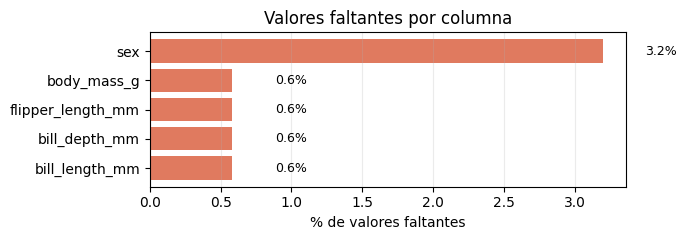

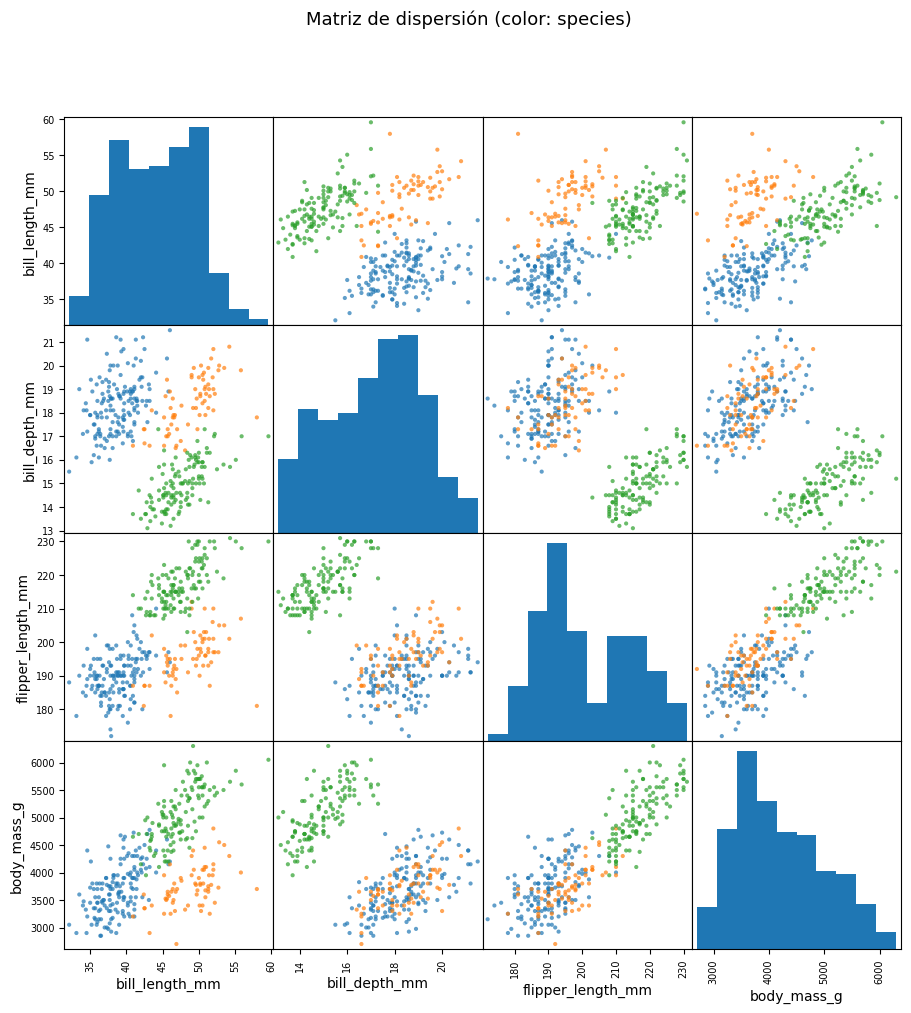

In [14]:
# ============================================================
# PASO 1: Cargar y explorar los datos
# ============================================================
import synaptix as sx
from synaptix.visualization import plot_missing, plot_scatter_matrix

df = sx.load_dataset("penguins")
print(f"Dimensiones: {df.shape}")

# ¿Cuántos nulos hay y dónde?
plot_missing(df)

# ¿Cómo se separan las especies según sus medidas?
plot_scatter_matrix(df, target="species", max_cols=4)

In [15]:
# ============================================================
# PASO 2: Limpieza automática + división train/test
# ============================================================
from synaptix.preprocessing import DataCleaner, train_test_split

# DataCleaner: imputa nulos (mediana/moda), codifica categóricas
# (one-hot) y escala numéricas — preservando la columna objetivo
cleaner = DataCleaner(impute_strategy="median", scale_method="standard")
df_listo = cleaner.clean(df, target="species")

X = df_listo.drop(columns="species")
y = df_listo["species"]

# stratify mantiene la proporción de especies en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entrenamiento: {len(X_train)} filas | Prueba: {len(X_test)} filas")
print(f"Features tras la limpieza: {list(X.columns)}")

Entrenamiento: 275 filas | Prueba: 69 filas
Features tras la limpieza: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Biscoe', 'island_Dream', 'island_Torgersen', 'sex_FEMALE', 'sex_MALE']


In [16]:
# ============================================================
# PASO 3: ¿Qué modelo funciona mejor? (AutoML-lite)
# ============================================================
from synaptix.model_selection import compare_models

# Entrena 7 clasificadores con validación cruzada de 5 folds
# y devuelve el ranking (solo con los datos de entrenamiento,
# el set de prueba queda intacto hasta el final)
ranking = compare_models(X_train, y_train, task="classification", cv=5, verbose=False)
ranking

,modelo,accuracy,desviacion,tiempo_s
0,LogisticRegression,0.992727,0.008907,0.076
1,SVMClassifier,0.989091,0.014545,0.071
2,RandomForestClassifier,0.985455,0.013606,1.166
3,KNNClassifier,0.985455,0.013606,0.051
4,GradientBoostingClassifier,0.981818,0.011499,3.732
5,DecisionTreeClassifier,0.952727,0.018542,0.048
6,NaiveBayes,0.720000,0.029542,0.029


In [17]:
# ============================================================
# PASO 4: Ajustar hiperparámetros del mejor modelo
# ============================================================
from synaptix.model_selection import GridSearch
from synaptix.supervised import RandomForestClassifier

# Rejilla de combinaciones a probar (3 x 3 = 9 modelos x 5 folds)
search = GridSearch(
    RandomForestClassifier(),
    {
        "n_estimators": [50, 100, 200],
        "max_depth": [4, 8, None],
    },
    cv=5,
)
modelo_final = search.fit(X_train, y_train)


=== GridSearch: RandomForestClassifier ===
  Mejor score : 0.9855
  Parámetros  : {'max_depth': 8, 'n_estimators': 50}



=== Evaluación: RandomForestClassifier ===
  accuracy    : 1.0000
  precision   : 1.0000
  recall      : 1.0000
  f1          : 1.0000


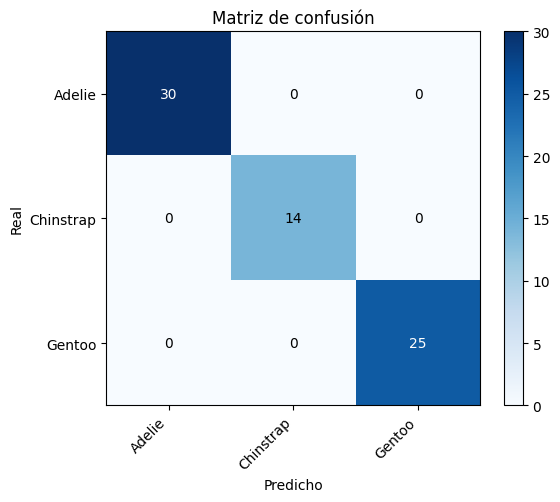

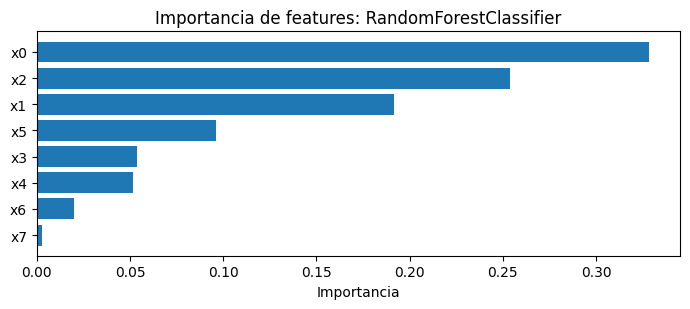

In [18]:
# ============================================================
# PASO 5: Evaluación final en el set de prueba (nunca visto)
# ============================================================
from synaptix.visualization import model_report, plot_feature_importance

# model_report: métricas + matriz de confusión, todo automático
resultados = model_report(modelo_final, X_test, y_test)

# ¿Qué medidas del pingüino pesan más en la decisión?
plot_feature_importance(modelo_final, top_n=8)

In [19]:
# ============================================================
# PASO 6: Guardar el modelo listo para producción
# ============================================================
modelo_final.save("modelo_penguins.pkl")

# En producción bastaría con:
modelo_produccion = RandomForestClassifier.load("modelo_penguins.pkl")
ejemplo = X_test.iloc[[0]]
print(f"Predicción para un pingüino nuevo: {modelo_produccion.predict(ejemplo)[0]}")
print(f"Valor real:                        {y_test.iloc[0]}")
ejemplo = X_test.iloc[[5]]
print(f"Predicción para un pingüino nuevo: {modelo_produccion.predict(ejemplo)[0]}")
print(f"Valor real:                        {y_test.iloc[5]}")

print("\nPipeline completo: cargar -> explorar -> limpiar -> comparar")
print("-> ajustar -> evaluar -> guardar. Todo con SynaptIX.")

Predicción para un pingüino nuevo: Adelie
Valor real:                        Adelie
Predicción para un pingüino nuevo: Adelie
Valor real:                        Adelie

Pipeline completo: cargar -> explorar -> limpiar -> comparar
-> ajustar -> evaluar -> guardar. Todo con SynaptIX.
